<a href="https://colab.research.google.com/github/NataliaFarieta/nataliafarieta/blob/main/Entregable_2_Machine__Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <center> **Aplicación  de validación cruzada en modelos de clasificación dataset Titanic**

##<center>Natalia Lucia Farieta Marín

###<center>*Maestría en Analítica de datos, Universidad Central*
###<center>**Machine Learning**
#### <center>Bogotá, Colombia



 <center>Febrero 20 de 2026

#**INTRODUCCIÓN**

El análisis de datos y los modelos de clasificación son herramientas fundamentales en la ciencia de datos para predecir variables categóricas y comprender los factores que influyen en determinados resultados. En específico, los algoritmos de clasificación supervisada permiten estimar la probabilidad de pertenecer a una clase a partir de variables predictoras, permitiendo la toma de decisiones basada en exploración cuantitativa.

El presente trabajo es una continuación del análisis predictivo realizado en el trayecto anterior, utilizando el conjunto de datos Titanic.csv, cuyo objetivo es predecir la variable de supervivencia (Survived) de los pasajeros del Titanic. Para este análisis de estudio se implementa técnicas de validación cruzada específicamente K-Fold y Stratified K-Fold para obtener estimaciones más robustas y representativas del desempeño real de los modelos de clasificación.

Primero, se realiza el preprocesamiento de los datos, incluyendo tratamiento de valores faltantes, transformación de variables y numeración de variables categóricas. Luego, se entrenan y comparan diversos modelos de clasificación. Su desempeño se evalúa mediante validación cruzada como K-Fold y Stratified K-Fold, analizando métricas como Accuracy, Recall, ROC-AUC y Balanced Accuracy, así como la desviación estándar para medir estabilidad del modelo. Finalmente, se selecciona el modelo que presenta el mejor equilibrio, rendimiento y predicción de datos.




##**Descripción de la base de datos Titanic.csv**

Para el desarrollo de la segunda parte del análisis, correspondiente al modelo de clasificación y validación cruzada, se emplea un subconjunto del dataset Titanic, el cual contiene información relevante de los pasajeros de la embarcación, con el objetivo de predecir su supervivencia durante el naufragio y evaluando cuál de los métodos de clasificación propuestos se desempeña mejor.

Cada fila representa un pasajero y describe características socioeconómicas y demográficas que influyen directamente en la probabilidad de supervivencia.


#**Variable objetivo**

**Survived**: la variable sobrevivir es el objetivo de estudio, ya que se busca predecir si un pasajero sobrevivió o no al desastre del Titanic. El propósito del modelo es predecir correctamente esta variable a partir de características de los pasajeros.

#**Variables predictorias**

Para el desarrollo del modelo de clasificación, se utilizaron múltiples variables predictoras, incluyendo tanto variables numéricas como categóricas, con el fin de identificar como estas influyen en la probabilidad de supervivencia.

Entre las principales variables estudiadas se encuentran:

**Pclass** (clase del pasajero)

**Sex** (sexo)

**Age** (edad)

**SibSp** (número de hermanos/esposos a bordo)

**Parch** (número de padres/hijos a bordo)

**Fare** (valor tiquete)

**Embarked** (puerto de embarque)

**Who** (clasificación demográfica: hombre, mujer, niño)

Estas variables fueron transformadas mediante un proceso de preprocesamiento que incluyó imputación de valores faltantes, escalamiento para variables numéricas y codificación One-Hot para variables categóricas.


##**Modelo de clasificación**

A diferencia de un estudio de pocas variables, realizado en el trayecto 1, en este trabajo se construyeron múltiples modelos de clasificación utilizando un conjunto ampliado de variables predictoras. Esto permitió evaluar de manera más completa la influencia conjunta de factores socioeconómicos y demográficos en la supervivencia.

La comparación entre modelos se realizó mediante matrices de confusión y métricas como Accuracy, Recall, F1-Score, ROC-AUC y Balanced Accuracy, empleando validación cruzada para garantizar estimaciones más robustas y estables del rendimiento.


##**Modelos implementados**


REGRESIÓN LOGÍSTICA

AdaBoost

Gradient Boosting

SVM (RBF)

SVM (Lineal)

K-NN (k=5)

Random Forest

Naive Bayes

Árbol de Decisión

##**Metricas calculadas**

Exactitud (Accuracy)

 ROC-AUC

 Balanced Accuracy

 DESVIACIÓN ESTÁNDAR




##**Importación de librerías**

En esta sección se importan las librerías necesarias para el desarrollo del análisis.

NumPy y Pandas: Manipulación y análisis de datos.

Matplotlib y Seaborn: Visualización de datos.

SciPy: Funciones estadísticas.

Se importan módulos para la División de datos, validación cruzada, optimización de hiperparámetros (GridSearch, RandomizedSearch), preprocesamiento de datos por escalamiento, imputacion y codificacion de variables categoricas, selección de características e inconrporación de modelos de clasificación (Logistic Regression, Random Forest, SVM, y por ultimo las metricas de evaluación.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold,
    StratifiedKFold, cross_validate, GridSearchCV,
    learning_curve, validation_curve, StratifiedShuffleSplit,
    RepeatedStratifiedKFold, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, roc_auc_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


##**Carga del dataset**

Se cargan el conjunto de datos Titanic desde un archivo CSV y se revisan las variables

In [ ]:
# Se cargan los datos (Titanic)
data = sns.load_dataset('titanic')

In [ ]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


##**Exploración del conjunto de datos**

La base de datos contiene 891 pasajeros y 13 variables predictoras.

La variable objetivo (survived) presenta la siguiente distribución: siendo 549 pasajeros (61.6%)que no sobrevivieron y 342 pasajeros (38.4%) que si sobrevivieron.

la media es de 13.02 y la desviacion estandar es de 13.39, lo que indica que existe alta dispersión en los datos, especialmente influenciada por variables como fare, que tiene valores en distintos rangos.

Los datos son heterogenos variables numéricas, lo que impica antes del modelado aplicar preprocesamiento de los datos.



 INFORMACIÓN GENERAL DEL DATASET TITANIC:
--------------------------------------------------
 • Dimensiones de características (X): (891, 13)
 • Dimensiones de variable objetivo (y): (891,)
 • Número de características: 13
 • Número de instancias: 891
 • Clases: ['No sobrevivió', 'Sobrevivió']
 • Codificación: 0 = No sobrevivió, 1 = Sobrevivió

 DISTRIBUCIÓN DE CLASES:
--------------------------------------------------
 • No sobrevivió: 549 instancias (61.6%)
 • Sobrevivió: 342 instancias (38.4%)

 ESTADÍSTICAS DESCRIPTIVAS (Variables Numéricas):
--------------------------------------------------
 • Características numéricas: pclass, age, sibsp, parch, fare...
 • Media de medias: 13.02
 • Desviación estándar promedio: 13.39


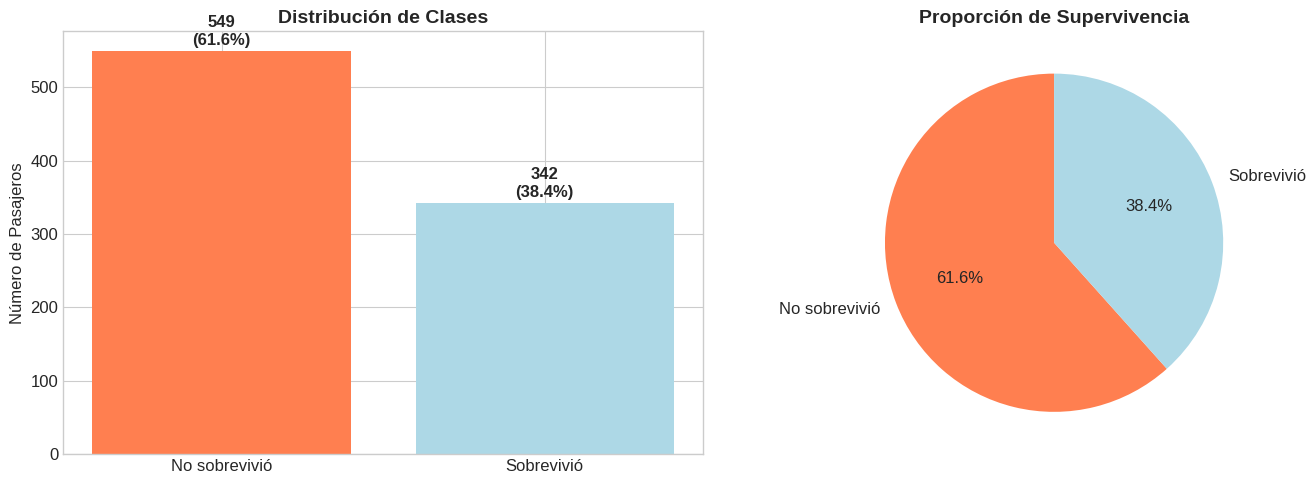

In [ ]:
data = data.drop(columns=["alive"], errors="ignore")

y = data["survived"]
X = data.drop(columns=["survived"])

target_names = ['No sobrevivió', 'Sobrevivió']

print("\n INFORMACIÓN GENERAL DEL DATASET TITANIC:")
print("-" * 50)
print(f" • Dimensiones de características (X): {X.shape}")
print(f" • Dimensiones de variable objetivo (y): {y.shape}")
print(f" • Número de características: {X.shape[1]}")
print(f" • Número de instancias: {X.shape[0]}")
print(f" • Clases: {target_names}")
print(f" • Codificación: 0 = {target_names[0]}, 1 = {target_names[1]}")

print(f"\n DISTRIBUCIÓN DE CLASES:")
print("-" * 50)
class_counts = y.value_counts()
class_percentages = y.value_counts(normalize=True) * 100

for i, class_name in enumerate(target_names):
    print(f" • {class_name}: {class_counts[i]} instancias ({class_percentages[i]:.1f}%)")

X_numeric = X.select_dtypes(include=np.number)

print(f"\n ESTADÍSTICAS DESCRIPTIVAS (Variables Numéricas):")
print("-" * 50)
print(f" • Características numéricas: {', '.join(X_numeric.columns[:5])}...")
print(f" • Media de medias: {X_numeric.mean().mean():.2f}")
print(f" • Desviación estándar promedio: {X_numeric.std().mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(target_names, class_counts, color=['coral', 'lightblue'])
axes[0].set_title('Distribución de Clases', fontweight='bold')
axes[0].set_ylabel('Número de Pasajeros')

for i, v in enumerate(class_counts):
    axes[0].text(i, v + 5, f'{v}\n({class_percentages[i]:.1f}%)',
                ha='center', va='bottom', fontweight='bold')

axes[1].pie(class_counts, labels=target_names, autopct='%1.1f%%',
           colors=['coral', 'lightblue'], startangle=90)
axes[1].set_title('Proporción de Supervivencia', fontweight='bold')

plt.tight_layout()
plt.show()

## PREPARACIÓN DE DATOS

Se procede a la división del dataset en: 80% entrenamiento y 20% prueba

Se utiliza stratify=y para mantener la proporción de clases y random_state=2026 para que los datos no cambien en cada ejecución y evita sesgos en la evaluación del modelo.

Se construye ColumnTransformer con dos pipelines: es decir que las variables numéricas se deben imputar con la media y el escalado con StandardScaler y en las variables categóricas se hace con la imputación con la moda


In [ ]:
# Separar datos

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=2026
)

numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("\n DATOS PROCESADOS - TITANIC")
print("-" * 50)
print(f"Entrenamiento: {X_train_processed.shape}")
print(f"Prueba:        {X_test_processed.shape}")

print("\n DISTRIBUCIÓN DE CLASES")
print("-" * 50)
print("Entrenamiento:")
print(f" • No sobrevivió: {np.sum(y_train==0)} ({np.mean(y_train==0)*100:.1f}%)")
print(f" • Sobrevivió:    {np.sum(y_train==1)} ({np.mean(y_train==1)*100:.1f}%)")
print("\nPrueba:")
print(f" • No sobrevivió: {np.sum(y_test==0)} ({np.mean(y_test==0)*100:.1f}%)")
print(f" • Sobrevivió:    {np.sum(y_test==1)} ({np.mean(y_test==1)*100:.1f}%)")



 DATOS PROCESADOS - TITANIC
--------------------------------------------------
Entrenamiento: (712, 22)
Prueba:        (179, 22)

 DISTRIBUCIÓN DE CLASES
--------------------------------------------------
Entrenamiento:
 • No sobrevivió: 439 (61.7%)
 • Sobrevivió:    273 (38.3%)

Prueba:
 • No sobrevivió: 110 (61.5%)
 • Sobrevivió:    69 (38.5%)


## DEFINICIÓN DE ESTRATEGIAS DE VALIDACIÓN CRUZADA

Se realiza la defición de las diferentes estrategias de validación cruzada  para evaluar el desempeño de los modelos de clasificación.

Se busca determinar que tan bien generaliza cada modelo a datos no vistos.

Se implementan las siguientes estrategias:

KFold (k=5 y k=10) que divide los datos en k particiones y rota cuál se usa como validación, se usa para evaluar la estabilidad.

StratifiedKFold (k=5 y k=10)
Similar a KFold, pero mantiene la proporción de supervivencia, aplicada en clases desbalanceadas.


RepeatedStratifiedKFold (5x3)
Repite el proceso estratificado 3 veces. Para tener estimaciones más estables y reduce la varianza.

StratifiedShuffleSplit
Genera múltiples divisiones aleatorias estratificadas.
Simula escenarios cercanos a situaciones reales de entrenamiento/prueba.

En general estas estrategias usadas sitven para mantener la proporción real de clases, evitan que alguna partición tenga muy pocos sobrevivientes y mejorar el rendimiento de los modelos.


In [ ]:
cv_strategies = {
    'KFold (k=5)': KFold(n_splits=5, shuffle=True, random_state=2026),
    'KFold (k=10)': KFold(n_splits=10, shuffle=True, random_state=2026),
    'StratifiedKFold (k=5)': StratifiedKFold(n_splits=5, shuffle=True, random_state=2026),
    'StratifiedKFold (k=10)': StratifiedKFold(n_splits=10, shuffle=True, random_state=2026),
    'RepeatedStratifiedKFold (5x3)': RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=2026),
    'StratifiedShuffleSplit': StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=2026),
}


## DEFINICIÓN DE MODELOS BASE

Se definen los modelos a aplicar:

**Regresión Logística**

**Random Forest**

**SVM** (Lineal y RBF)

**K-Nearest Neighbors**

**Gradient Boosting, AdaBoost**

**Naive Bayes**

Al usar estos modelos se desea evaluar cual se adapta mejor a clasificar datos no vistos.



In [ ]:
modelos_base = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=2026),
    'Árbol de Decisión':   DecisionTreeClassifier(random_state=2026),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=2026),
    'SVM (Lineal)':        SVC(kernel='linear', probability=True, random_state=2026),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=2026),
    'K-NN (k=5)':          KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=2026),
    'AdaBoost':            AdaBoostClassifier(random_state=2026),
    'Naive Bayes':         GaussianNB(),
}

In [ ]:
modelos_pipeline = {}

for nombre, modelo in modelos_base.items():
    modelos_pipeline[nombre] = Pipeline([
        ('preprocesamiento', preprocessor),
        ('modelo', modelo)
    ])


## FUNCIÓN PARA VALIDACIÓN CRUZADA COMPARATIVA

In [ ]:


def validacion_cruzada_completa(modelos, X, y, cv_dict):

    scoring = {
        'accuracy':          'accuracy',
        'balanced_accuracy': 'balanced_accuracy',
        'precision':         'precision_weighted',
        'recall':            'recall_weighted',
        'f1':                'f1_weighted',
        'roc_auc':           'roc_auc',
    }

    resultados = {}

    for nombre_modelo, modelo in modelos.items():
        resultados[nombre_modelo] = {}

        for nombre_cv, estrategia_cv in cv_dict.items():

            scores = cross_validate(
                modelo, X, y,
                cv=estrategia_cv,
                scoring=scoring,
                return_train_score=True
            )

            resultados[nombre_modelo][nombre_cv] = {}

            for metrica in scoring.keys():
                resultados[nombre_modelo][nombre_cv][metrica] = {
                    'test_mean':  scores[f'test_{metrica}'].mean(),
                    'test_std':   scores[f'test_{metrica}'].std(),
                    'train_mean': scores[f'train_{metrica}'].mean(),
                }

    return resultados


## EJECUCIÓN DE VALIDACIÓN CRUZADA

In [ ]:
resultados_cv = validacion_cruzada_completa(
    modelos_pipeline,
    X_train,
    y_train,
    cv_strategies
)



## ANÁLISIS DE RESULTADOS DE VALIDACIÓN CRUZADA


RANKING FINAL DE MODELOS (StratifiedKFold k=5)
----------------------------------------------------------------------
 Ranking              Modelo Accuracy (±Std)  F1 Score  ROC-AUC
       1 Regresión Logística 0.8301 ± 0.0298  0.829431 0.868025
       2           SVM (RBF) 0.8231 ± 0.0227  0.818114 0.852307
       3        SVM (Lineal) 0.8132 ± 0.0251  0.812110 0.851598
       4            AdaBoost 0.8132 ± 0.0123  0.813454 0.870094
       5   Gradient Boosting 0.8118 ± 0.0206  0.808886 0.868465
       6          K-NN (k=5)  0.809 ± 0.0081  0.805744 0.850840
       7       Random Forest  0.802 ± 0.0195  0.800712 0.859309
       8         Naive Bayes 0.7823 ± 0.0339  0.776538 0.837302
       9   Árbol de Decisión  0.781 ± 0.0217  0.781179 0.768522


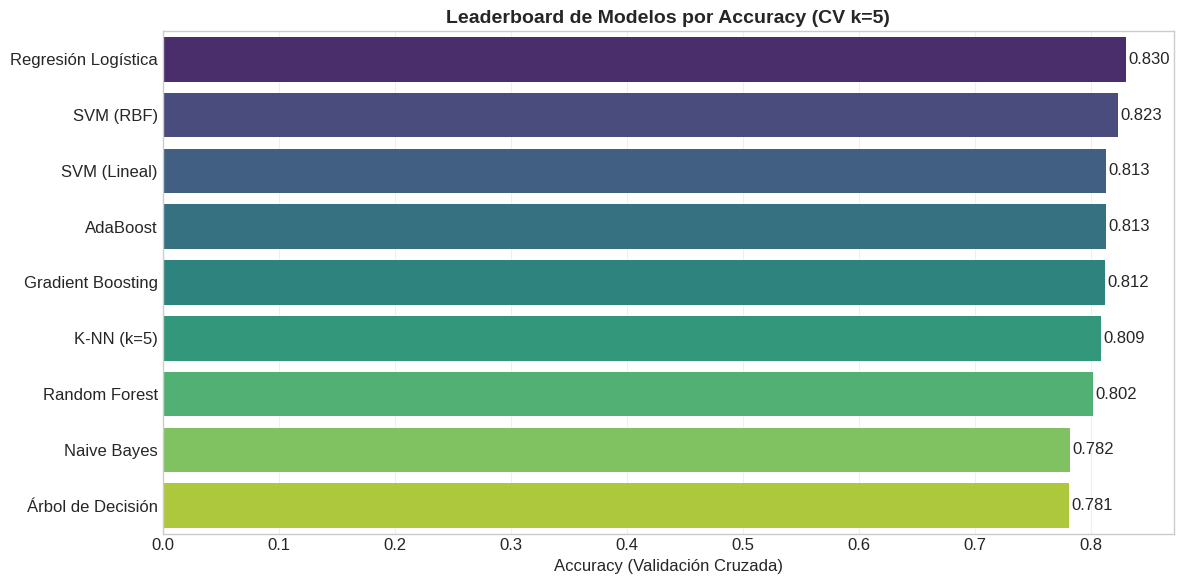

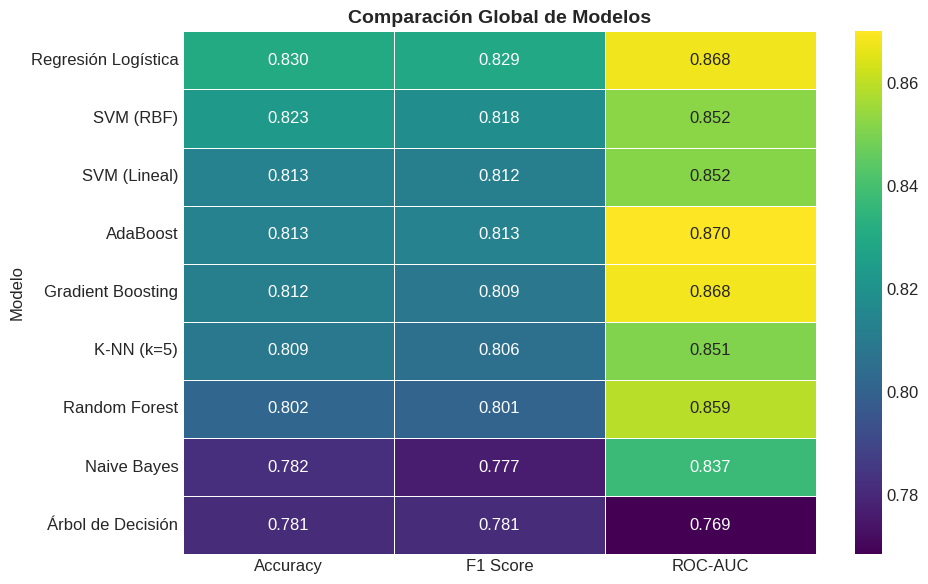

In [ ]:
resumen_data = []

for modelo_nombre, cv_results in resultados_cv.items():

    clave_cv = 'StratifiedKFold (k=5)'

    if clave_cv in cv_results:
        metricas = cv_results[clave_cv]

        resumen_data.append({
            'Modelo':        modelo_nombre,
            'Accuracy':      metricas['accuracy']['test_mean'],
            'Std_Accuracy':  metricas['accuracy']['test_std'],
            'F1 Score':      metricas['f1']['test_mean'],
            'ROC-AUC':       metricas['roc_auc']['test_mean'],
        })

resumen_df = (pd.DataFrame(resumen_data)
              .sort_values('Accuracy', ascending=False)
              .reset_index(drop=True))
resumen_df['Ranking'] = resumen_df.index + 1

resumen_df['Accuracy (±Std)'] = (
    resumen_df['Accuracy'].round(4).astype(str)
    + " ± "
    + resumen_df['Std_Accuracy'].round(4).astype(str)
)

tabla_final = resumen_df[['Ranking', 'Modelo', 'Accuracy (±Std)', 'F1 Score', 'ROC-AUC']]

print("\nRANKING FINAL DE MODELOS (StratifiedKFold k=5)")
print("-" * 70)
print(tabla_final.to_string(index=False))

# — Leaderboard —
plt.figure(figsize=(12, 6))
sns.barplot(data=resumen_df, y="Modelo", x="Accuracy", palette="viridis")
plt.title("Leaderboard de Modelos por Accuracy (CV k=5)", fontweight='bold')
plt.xlabel("Accuracy (Validación Cruzada)")
plt.ylabel("")
plt.grid(axis='x', alpha=0.3)
for index, value in enumerate(resumen_df["Accuracy"]):
    plt.text(value + 0.002, index, f"{value:.3f}", va='center')
plt.tight_layout()
plt.show()

# — Heatmap comparativo —
metricas_heatmap = resumen_df.set_index("Modelo")[["Accuracy", "F1 Score", "ROC-AUC"]]
plt.figure(figsize=(10, 6))
sns.heatmap(metricas_heatmap, annot=True, cmap="viridis",
            fmt=".3f", linewidths=0.5)
plt.title("Comparación Global de Modelos", fontweight='bold')
plt.tight_layout()
plt.show()



Se evaluaron 9 modelos de clasificación usando validación cruzada estratificada, comparándolos en tres métricas específicamente Accuracy, F1 Score y ROC-AUC.

Para este apartado la regresión Logística es el modelo ganador con el mejor equilibrio general Accuracy: 0.830, F1: 0.829, ROC-AUC: 0.868 y posee estabilidad en sus datos por su baja desviación estándar.

AdaBoost posee un alto ROC-AUC 0.870, pero tiene un menor accuracy 0.813, es decir que discrimina bien entre clases, pero puede estar menos calibrado.

Los SVMs consistentes: el SVM (RBF) tiene un accuracy 0.823 con buena generalización de datos y SVM (Lineal) rinde un poco menos.

Gradient Boosting muestra buen ROC-AUC 0.868 con con accuracy de 0.812, siendo una buena opción se tiene más en cuenta la discriminación de datos.

Random Forest, K-NN y Naive Bayes posee accuracy de 0.78 y 0.81 respectivamente, teniendo un rendimiento intermedio.

Árbol de Decisión tiene un ROC-AUC 0.769, por lo que es posible que se sobreajuste.

La imagen 1 grafico de barras indica que la diferencia entre los 5 primeros modelos es pequeña con respecto al accuracy, haciendo más difícil la elección del modelo. Sin embargo, la regresión Logística tiene el mejor accuracy y F1, y un buen ROC-AUC.



## ANÁLISIS DE SESGO-VARIANZA


ANÁLISIS SESGO - VARIANZA
-----------------------------------------------------------------
 • Accuracy bajo (<0.70) → Alto SESGO (Underfitting)
 • Std alto (>0.05)      → Alta VARIANZA (Modelo inestable)
 • Accuracy alto + Std bajo → Buen equilibrio

 • Regresión Logística: Accuracy=0.830 | Std=0.0298 → BUEN EQUILIBRIO
 • SVM (RBF): Accuracy=0.823 | Std=0.0227 → BUEN EQUILIBRIO
 • SVM (Lineal): Accuracy=0.813 | Std=0.0251 → BUEN EQUILIBRIO
 • AdaBoost: Accuracy=0.813 | Std=0.0123 → BUEN EQUILIBRIO
 • Gradient Boosting: Accuracy=0.812 | Std=0.0206 → BUEN EQUILIBRIO
 • K-NN (k=5): Accuracy=0.809 | Std=0.0081 → BUEN EQUILIBRIO
 • Random Forest: Accuracy=0.802 | Std=0.0195 → BUEN EQUILIBRIO
 • Naive Bayes: Accuracy=0.782 | Std=0.0339 → BUEN EQUILIBRIO
 • Árbol de Decisión: Accuracy=0.781 | Std=0.0217 → BUEN EQUILIBRIO


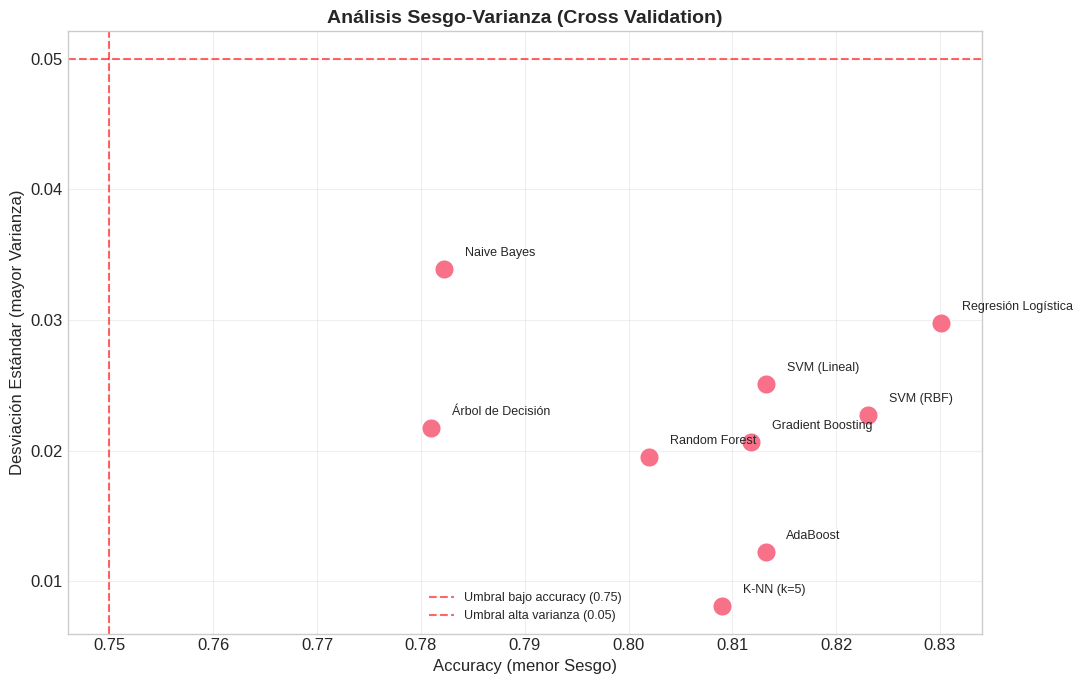

In [ ]:
print("\nANÁLISIS SESGO - VARIANZA")
print("-" * 65)
print(" • Accuracy bajo (<0.70) → Alto SESGO (Underfitting)")
print(" • Std alto (>0.05)      → Alta VARIANZA (Modelo inestable)")
print(" • Accuracy alto + Std bajo → Buen equilibrio\n")

for idx, row in resumen_df.iterrows():
    acc = row['Accuracy']
    std = row['Std_Accuracy']

    if acc < 0.70:
        diagnostico = "ALTO SESGO (Underfitting)"
    elif std > 0.05:
        diagnostico = "ALTA VARIANZA (Inestable)"
    else:
        diagnostico = "BUEN EQUILIBRIO"

    print(f" • {row['Modelo']}: Accuracy={acc:.3f} | Std={std:.4f} → {diagnostico}")

plt.figure(figsize=(11, 7))

sns.scatterplot(data=resumen_df, x="Accuracy", y="Std_Accuracy", s=200)

for i in range(len(resumen_df)):
    plt.text(
        resumen_df["Accuracy"].iloc[i] + 0.002,
        resumen_df["Std_Accuracy"].iloc[i] + 0.001,
        resumen_df["Modelo"].iloc[i],
        fontsize=9
    )

plt.axvline(x=0.75, linestyle="--", color="red", alpha=0.6,
            label="Umbral bajo accuracy (0.75)")
plt.axhline(y=0.05, linestyle="--", color="red", alpha=0.6,
            label="Umbral alta varianza (0.05)")

plt.title("Análisis Sesgo-Varianza (Cross Validation)", fontweight='bold')
plt.xlabel("Accuracy (menor Sesgo)")
plt.ylabel("Desviación Estándar (mayor Varianza)")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

El grafico determina que el accuracy que este a la derecha tiene un menor sesgo es decir la regresión logística y la desviación estándar más baja indica una menor varianza en este caso el K-NN.
El K-NN es el modelo más estable con una Std = 0.0081, con el menor nivel de varianza de todos. Su accuracy es competitivo 0.809.
AdaBoost también tiene una buena Std = 0.0123 con un accuracy de 0.813.
Regresión Logística tiene el mayor accuracy 0.830 pero con la mayor varianza por lo que lo hace el modelo más frágil al momento de partir los datos.
Naive Bayes y árbol de decisiones son los modelos menos favorables, siendo modelos poco recomendables para esta dataset.


## ANÁLISIS DE CURVAS ROC Y PRECISION-RECALL

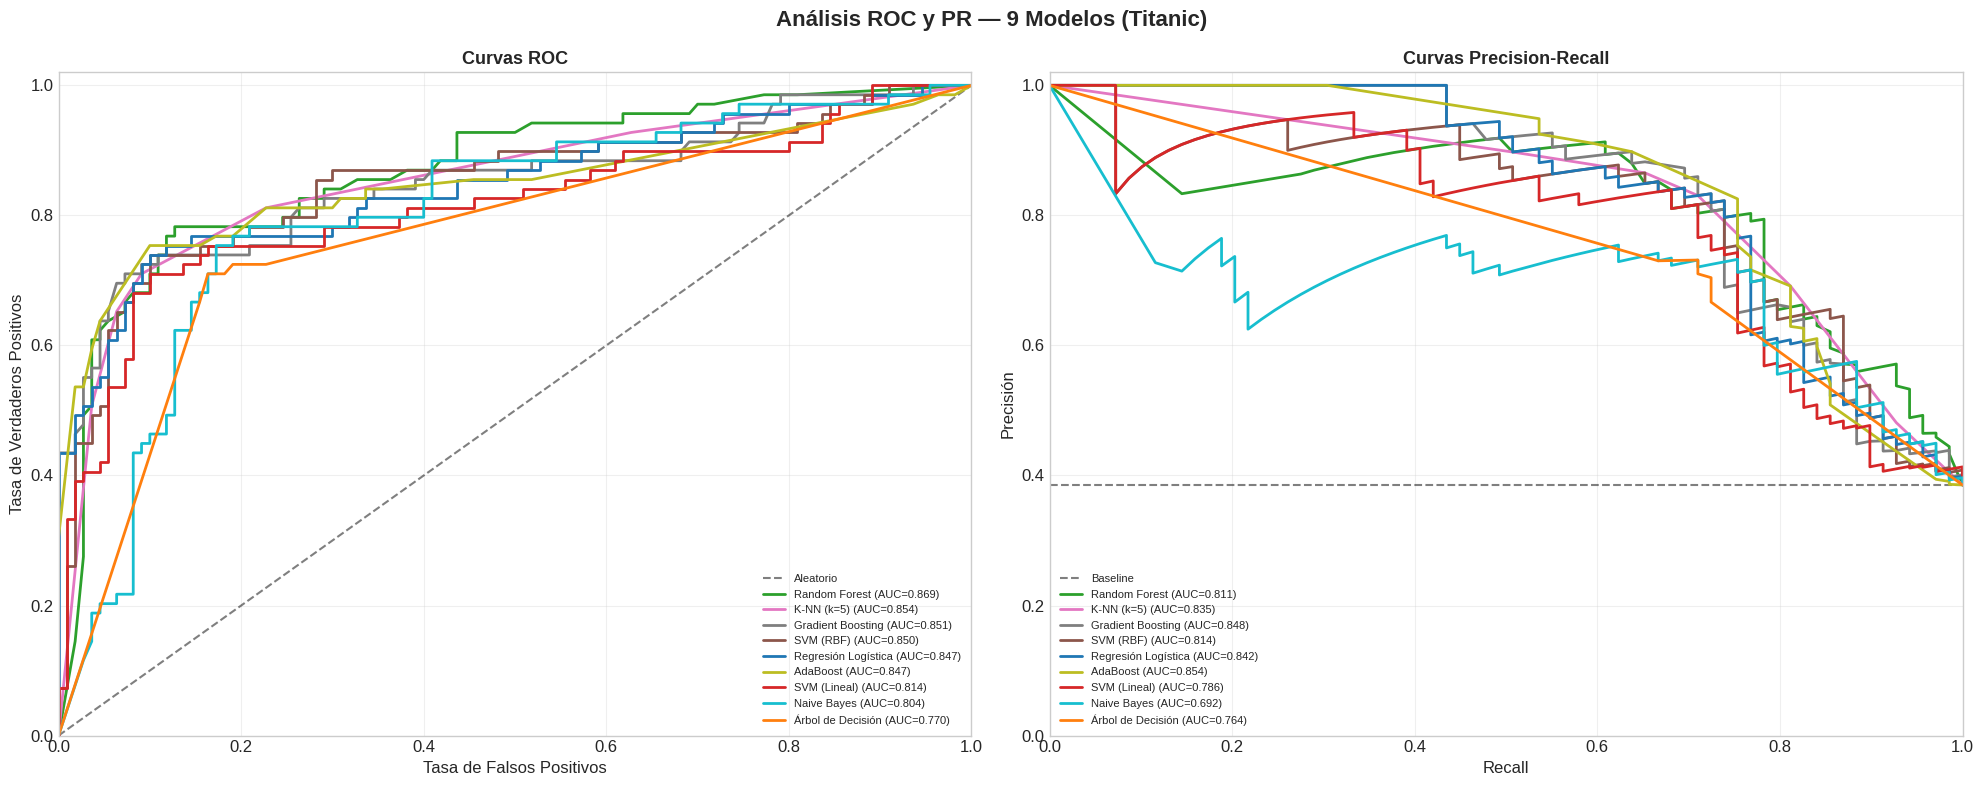

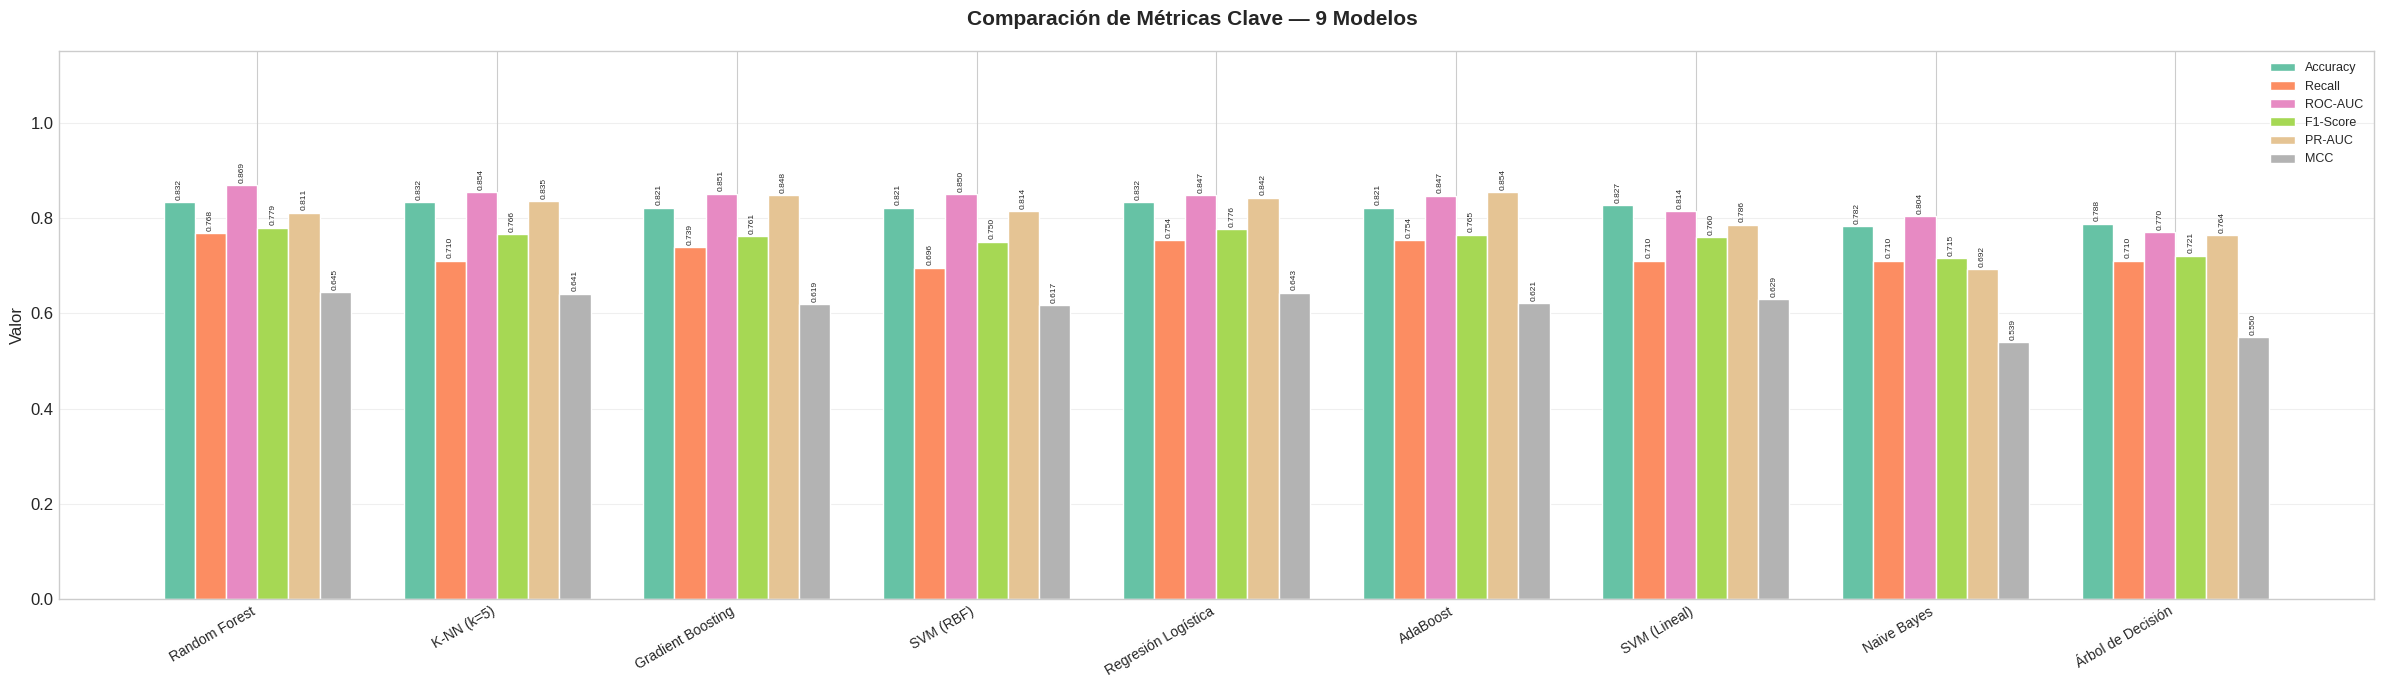

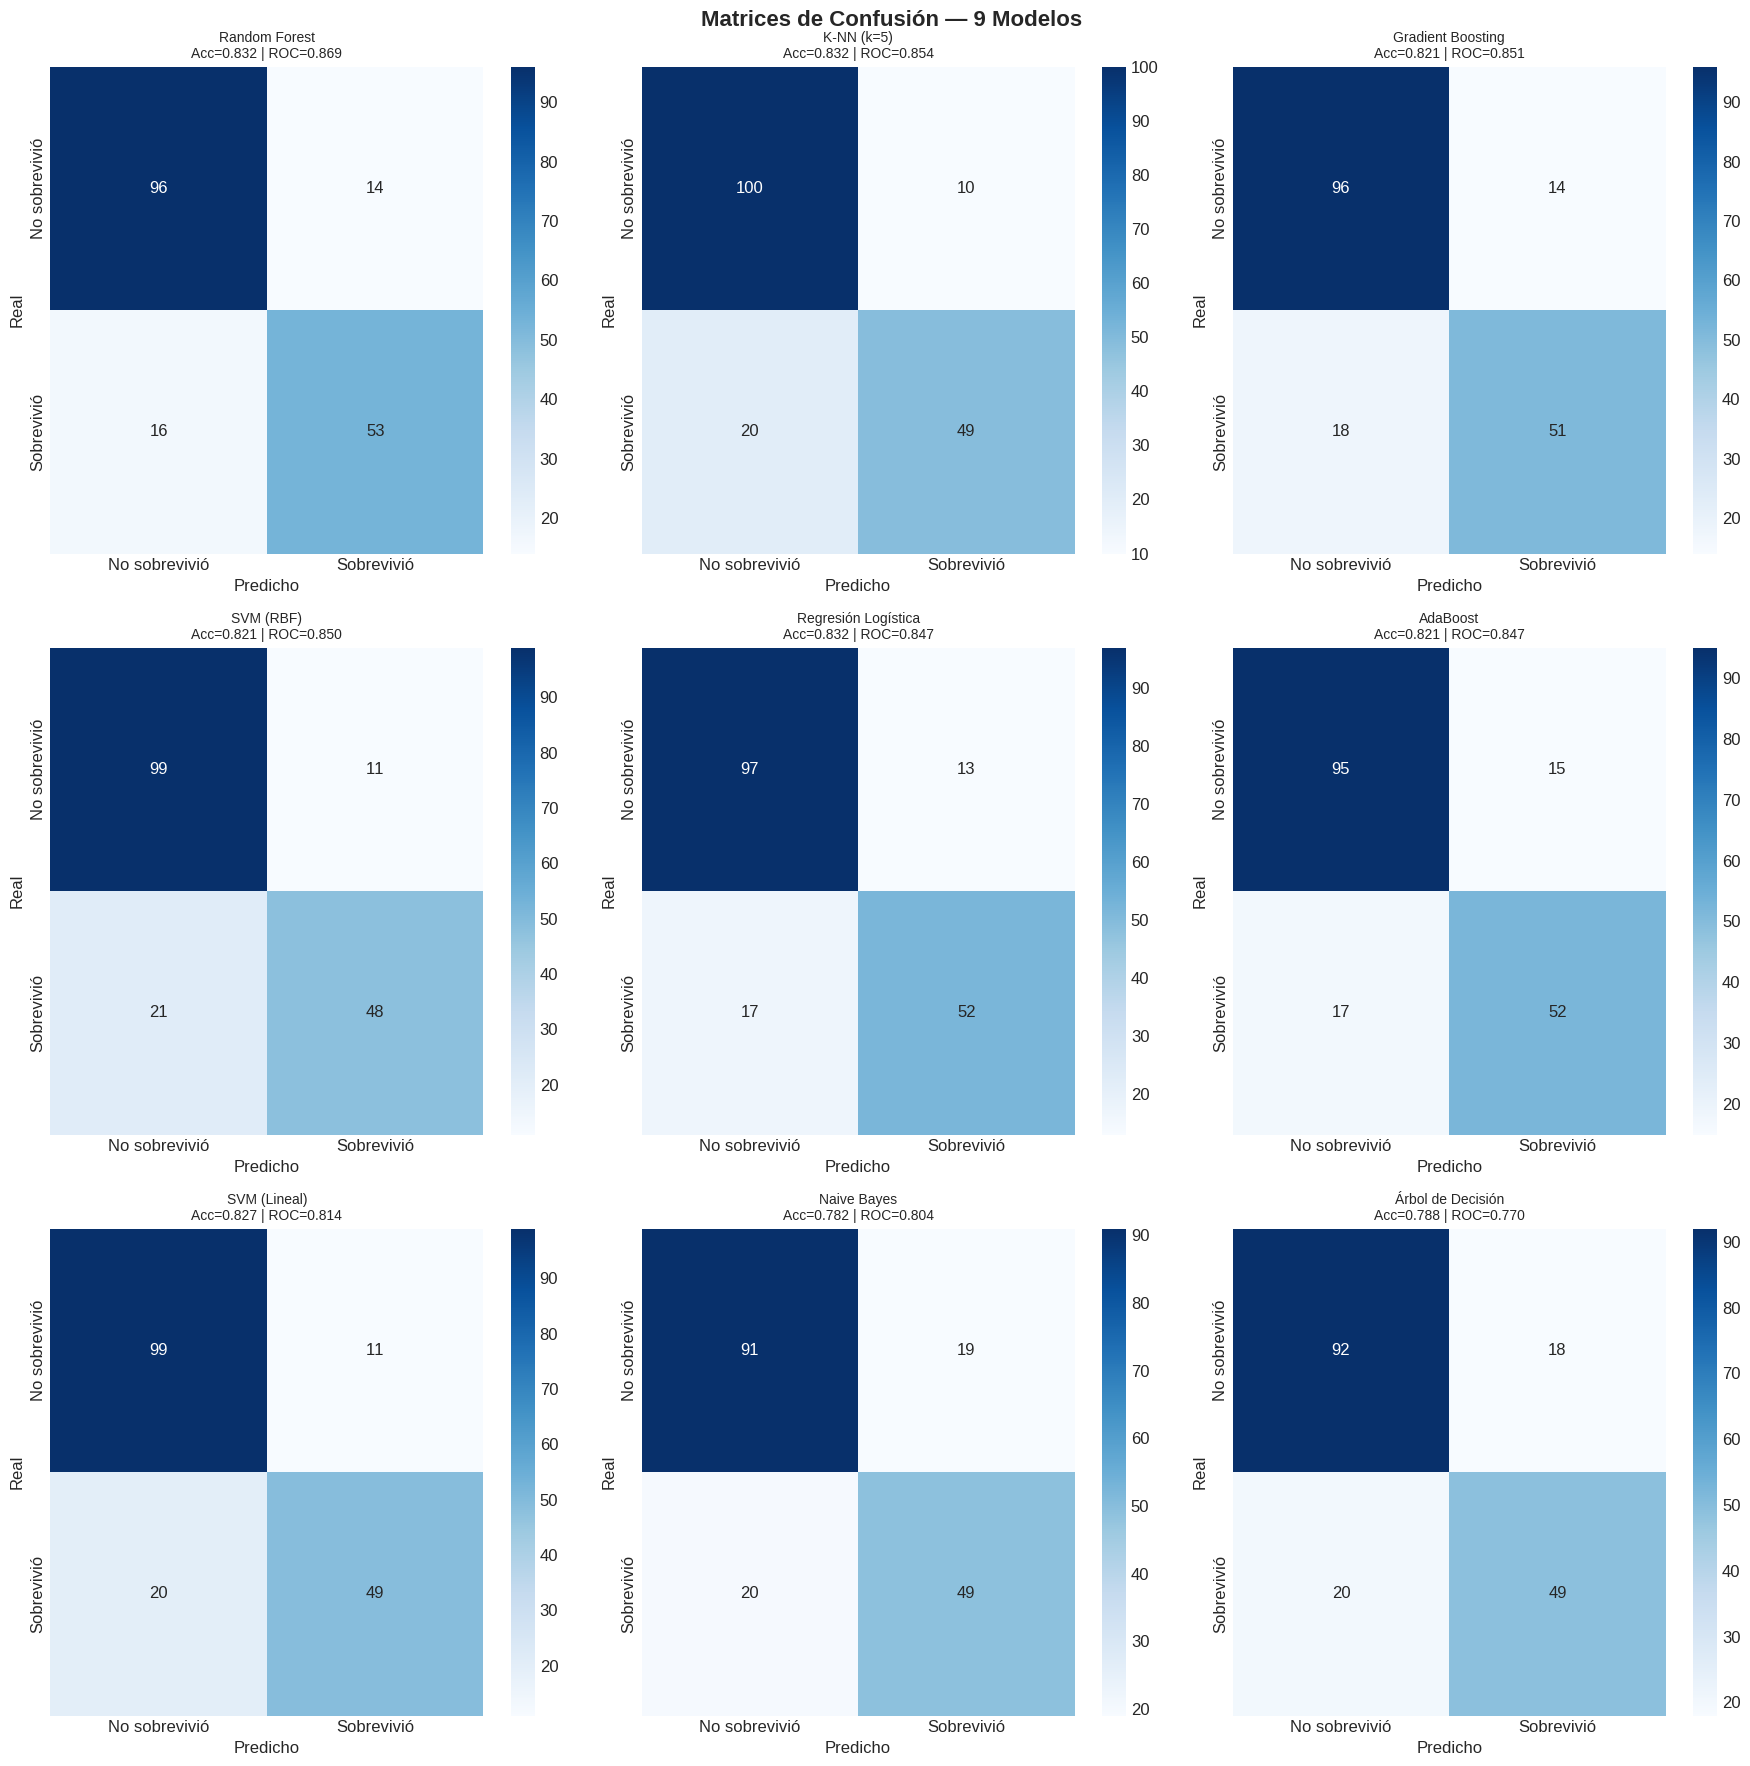


RESULTADOS FINALES EN TEST — 9 MODELOS
             Modelo  Accuracy  Balanced Acc  Precision  Recall  F1-Score  ROC-AUC  PR-AUC    MCC  Kappa
      Random Forest    0.8324        0.8204     0.7910  0.7681    0.7794   0.8691  0.8106 0.6445 0.6443
         K-NN (k=5)    0.8324        0.8096     0.8305  0.7101    0.7656   0.8544  0.8347 0.6412 0.6364
  Gradient Boosting    0.8212        0.8059     0.7846  0.7391    0.7612   0.8510  0.8480 0.6192 0.6185
          SVM (RBF)    0.8212        0.7978     0.8136  0.6957    0.7500   0.8503  0.8145 0.6167 0.6122
Regresión Logística    0.8324        0.8177     0.8000  0.7536    0.7761   0.8474  0.8423 0.6431 0.6424
           AdaBoost    0.8212        0.8086     0.7761  0.7536    0.7647   0.8468  0.8539 0.6208 0.6206
       SVM (Lineal)    0.8268        0.8051     0.8167  0.7101    0.7597   0.8144  0.7859 0.6291 0.6253
        Naive Bayes    0.7821        0.7687     0.7206  0.7101    0.7153   0.8036  0.6920 0.5389 0.5389
  Árbol de Decisión    0

In [ ]:
resultados_curvas = []
colors = plt.cm.tab10(np.linspace(0, 1, len(modelos_pipeline)))  # ← tab10 en lugar de viridis


# ENTRENAMIENTO

for idx, (nombre, modelo) in enumerate(modelos_pipeline.items()):  # ← modelos_pipeline

    modelo.fit(X_train, y_train)

    # Probabilidades o scores normalizados
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
    else:
        y_scores = modelo.decision_function(X_test)
        y_proba  = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min())

    # Curvas ROC y PR
    fpr, tpr, _      = roc_curve(y_test, y_proba)
    roc_auc          = auc(fpr, tpr)
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_proba)
    pr_auc           = auc(rec_c, prec_c)

    # Predicciones y métricas
    y_pred       = modelo.predict(X_test)
    accuracy     = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    precision_val= precision_score(y_test, y_pred)
    recall_val   = recall_score(y_test, y_pred)
    f1           = f1_score(y_test, y_pred)
    mcc          = matthews_corrcoef(y_test, y_pred)
    kappa        = cohen_kappa_score(y_test, y_pred)
    cm           = confusion_matrix(y_test, y_pred)

    resultados_curvas.append({
        'Modelo':       nombre,
        'Color':        colors[idx],
        'FPR':          fpr,
        'TPR':          tpr,
        'Precision_c':  prec_c,
        'Recall_c':     rec_c,
        'Accuracy':     accuracy,
        'Balanced Acc': balanced_acc,
        'Precision':    precision_val,
        'Recall':       recall_val,
        'F1-Score':     f1,
        'ROC-AUC':      roc_auc,
        'PR-AUC':       pr_auc,
        'MCC':          mcc,
        'Kappa':        kappa,
        'CM':           cm,
    })

# Ordenar por ROC-AUC (más robusto que Accuracy ante desbalance)
resultados_curvas = sorted(resultados_curvas,
                           key=lambda x: x['ROC-AUC'],   # ← cambiado de Accuracy
                           reverse=True)


# FIGURA 1 — CURVAS ROC Y PRECISION-RECALL


fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Análisis ROC y PR — 9 Modelos (Titanic)',
             fontsize=16, fontweight='bold')

ax_roc = axes[0]
ax_pr  = axes[1]

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Aleatorio')
ax_pr.axhline(y=np.mean(y_test), color='k', linestyle='--',
              lw=1.5, alpha=0.5, label='Baseline')

for r in resultados_curvas:
    ax_roc.plot(r['FPR'], r['TPR'], lw=2, color=r['Color'],
                label=f"{r['Modelo']} (AUC={r['ROC-AUC']:.3f})")
    ax_pr.plot(r['Recall_c'], r['Precision_c'], lw=2, color=r['Color'],
               label=f"{r['Modelo']} (AUC={r['PR-AUC']:.3f})")

for ax, titulo, loc in zip(
        [ax_roc, ax_pr],
        ['Curvas ROC', 'Curvas Precision-Recall'],
        ['lower right', 'lower left']):
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, loc=loc)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

ax_roc.set_xlabel('Tasa de Falsos Positivos')
ax_roc.set_ylabel('Tasa de Verdaderos Positivos')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precisión')

plt.tight_layout()
plt.show()


# FIGURA 2 — COMPARACIÓN DE MÉTRICAS


metricas_clave = ['Accuracy', 'Recall', 'ROC-AUC', 'F1-Score', 'PR-AUC', 'MCC']
nombres        = [r['Modelo'] for r in resultados_curvas]
x              = np.arange(len(resultados_curvas))
width          = 0.13   # ← ajustado para 6 barras por modelo sin solapamiento

fig, ax = plt.subplots(figsize=(24, 7))   # ← figura más ancha para 9 modelos
fig.suptitle('Comparación de Métricas Clave — 9 Modelos',
             fontsize=15, fontweight='bold')

palette = plt.cm.Set2(np.linspace(0, 1, len(metricas_clave)))

for i, (metrica, color) in enumerate(zip(metricas_clave, palette)):
    valores = [r[metrica] for r in resultados_curvas]
    bars = ax.bar(x + width * i, valores, width,
                  label=metrica, color=color, edgecolor='white')
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=6, rotation=90)

ax.set_xticks(x + width * (len(metricas_clave) / 2 - 0.5))
ax.set_xticklabels(nombres, rotation=30, ha='right', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Valor')
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# FIGURA 3 — MATRICES DE CONFUSIÓN


cols_cm = 3
rows_cm = int(np.ceil(len(resultados_curvas) / cols_cm))

fig_cm, axes_cm = plt.subplots(rows_cm, cols_cm, figsize=(18, 6 * rows_cm))
axes_cm = axes_cm.flatten()

for idx, r in enumerate(resultados_curvas):
    sns.heatmap(
        r['CM'], annot=True, fmt='d', cmap='Blues',
        ax=axes_cm[idx],
        xticklabels=['No sobrevivió', 'Sobrevivió'],
        yticklabels=['No sobrevivió', 'Sobrevivió'],
    )
    axes_cm[idx].set_title(           # ← añadido ROC-AUC al título
        f"{r['Modelo']}\n"
        f"Acc={r['Accuracy']:.3f} | ROC={r['ROC-AUC']:.3f}",
        fontsize=10
    )
    axes_cm[idx].set_xlabel('Predicho')
    axes_cm[idx].set_ylabel('Real')

for j in range(idx + 1, len(axes_cm)):
    fig_cm.delaxes(axes_cm[j])

plt.suptitle('Matrices de Confusión — 9 Modelos',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# TABLA

cols_tabla = ['Modelo', 'Accuracy', 'Balanced Acc', 'Precision',
              'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC', 'MCC', 'Kappa']

resultados_df = pd.DataFrame([         # ← excluye CM, FPR, TPR, etc.
    {k: r[k] for k in cols_tabla} for r in resultados_curvas
])

print("\nRESULTADOS FINALES EN TEST — 9 MODELOS")
print("=" * 80)
print(resultados_df.round(4).to_string(index=False))

# Resumen del mejor modelo
mejor = resultados_curvas[0]
print(f"\n{'='*50}")
print(f"  MEJOR MODELO : {mejor['Modelo']}")
print(f"  ROC-AUC      : {mejor['ROC-AUC']:.4f}")
print(f"  Accuracy     : {mejor['Accuracy']:.4f}")
print(f"  F1-Score     : {mejor['F1-Score']:.4f}")
print(f"  MCC          : {mejor['MCC']:.4f}")
print(f"{'='*50}")

El grafico 1 Curvas ROC y Precision-Recall indica que Random Forest lidera con un mayo área AUC=0.869, seguido por K-NN 0.854 y Gradient Boosting 0.851. Árbol de Decisión 0.770 y Naive Bayes 0.804 siguen confirmando el bajo rendimiento.

En la curva Precision-Recall que informa el desbalance de clases del Titanic, los modelos Gradient Boosting y AdaBoost tienen AUC más altos 0.848 y 0.854 respectivamente, por lo que tienen un mejor balance, mientras que K-NN tiene un PR-AUC=0.835, considerándose el mejor modelo para predecir sobrevivientes sin sacrificar precisión.



En el grafico 2 de Comparación de Métricas, los 6 primeros modelos son muy similares en Accuracy 0.82, el modelo Random Forest tiene el MCC más alto 0.6445, indicando la mejor correlación. K-NN posee una precisión alta 0.830 pero Recall bajo 0.710, lo que significa que cuando predice que si sobrevivió casi siempre acierta, pero deja escapar más sobrevivientes reales.
SVM (RBF) y SVM (Lineal) tienen el mismo patrón de alta precisión y bajo recall.
Naive Bayes y Árbol de Decisión tiene bajas métricas.



En las matrices de confusión el modelo Random Forest tiene la mayor cantidad de sobrevivientes reales 53 con solo 16 falsos negativos, el mejor resultado absoluto. K-NN tiene solo 10 falsos positivos, pero pierde 20 sobrevivientes reales.

Existen un patrón de sensibilidad entre Random Forest, Regresión Logística y AdaBoost priorizan encontrar sobrevivientes reales, si el costo de perder un sobreviviente es alto. Los modelos K-NN y SVMs no generar falsas alarmas.


Usando Random Forest base (sin optimizar)


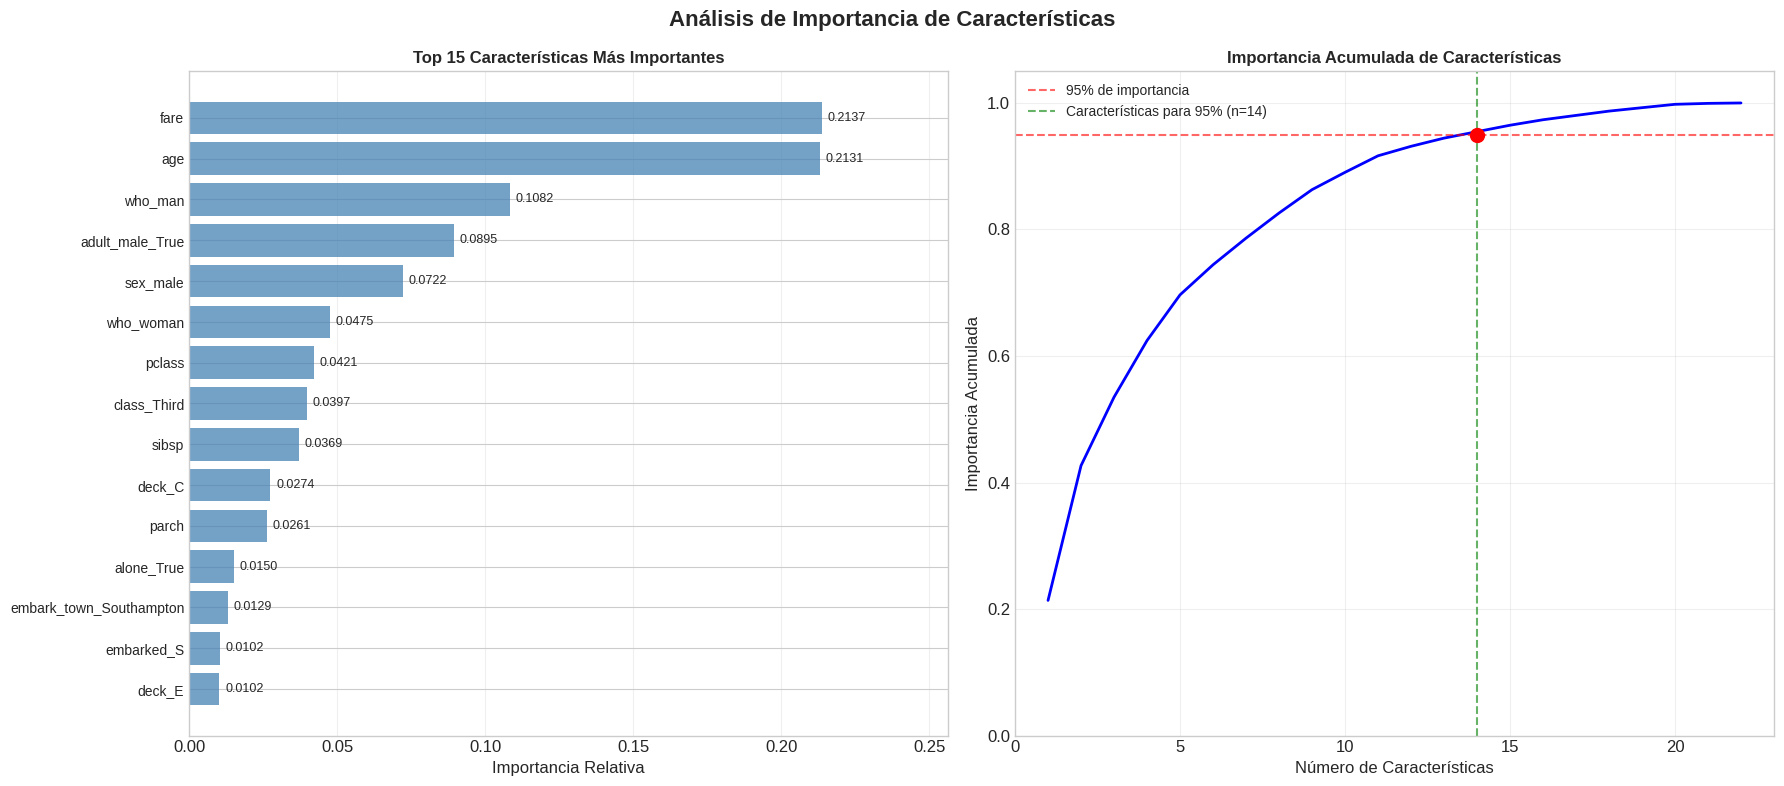


 RESUMEN DE IMPORTANCIA:
--------------------------------------------------
 • Total de características:              22
 • Características para 95% importancia: 14
 • Reducción posible:                     8 características (36.4%)

 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES:
--------------------------------------------------
  1. fare                           : 0.2137
  2. age                            : 0.2131
  3. who_man                        : 0.1082
  4. adult_male_True                : 0.0895
  5. sex_male                       : 0.0722
  6. who_woman                      : 0.0475
  7. pclass                         : 0.0421
  8. class_Third                    : 0.0397
  9. sibsp                          : 0.0369
 10. deck_C                         : 0.0274


In [ ]:

# Usar versión optimizada si existe, si no la base
if 'mejores_modelos_optimizados' in dir() and 'Random Forest' in mejores_modelos_optimizados:
    rf_pipeline = mejores_modelos_optimizados['Random Forest']
    print("Usando Random Forest optimizado (GridSearch)")
else:
    rf_pipeline = modelos_pipeline['Random Forest']
    print("Usando Random Forest base (sin optimizar)")

# Entrenar siempre para garantizar que el pipeline está ajustado
rf_pipeline.fit(X_train, y_train)



# Acceso seguro al paso del modelo dentro del pipeline
paso_modelo = rf_pipeline.named_steps.get('modelo', None)

if paso_modelo is None:
    raise ValueError("No se encontró el paso 'modelo' en el pipeline. "
                     "Verifica que el pipeline fue construido con el nombre 'modelo'.")

# Nombres de características desde el preprocesador
paso_prep   = rf_pipeline.named_steps['preprocesamiento']
feature_names_raw = paso_prep.get_feature_names_out()

# Limpiar prefijos verbose (num__, cat__) para mejor legibilidad
feature_names = [
    name.replace('num__', '').replace('cat__', '')
    for name in feature_names_raw
]



importancias  = paso_modelo.feature_importances_
indices       = np.argsort(importancias)[::-1]
n_top         = 15  # Top características a mostrar
n_features    = len(importancias)

#GRAFICOS

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Análisis de Importancia de Características',
             fontsize=16, fontweight='bold')

# — Gráfico 1: Barras horizontales Top N —
top_importancias = importancias[indices][:n_top]
top_nombres      = [feature_names[i] for i in indices[:n_top]]

bars = axes[0].barh(range(n_top), top_importancias,
                    color='steelblue', alpha=0.75)

# Anotaciones con valor numérico sobre cada barra
for bar, val in zip(bars, top_importancias):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center', ha='left', fontsize=9)

axes[0].set_yticks(range(n_top))
axes[0].set_yticklabels(top_nombres, fontsize=10)
axes[0].set_xlabel('Importancia Relativa')
axes[0].set_title(f'Top {n_top} Características Más Importantes',
                  fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlim([0, top_importancias.max() * 1.2])  # margen para etiquetas
axes[0].grid(True, alpha=0.3, axis='x')

# — Gráfico 2: Importancia acumulada —
importancias_acumuladas = np.cumsum(importancias[indices])
punto_95 = np.where(importancias_acumuladas >= 0.95)[0][0] + 1  # índice base 1

axes[1].plot(range(1, n_features + 1), importancias_acumuladas,
             'b-', linewidth=2)

axes[1].axhline(y=0.95, color='r', linestyle='--', alpha=0.6,
                label='95% de importancia')
axes[1].axvline(x=punto_95, color='g', linestyle='--', alpha=0.6,
                label=f'Características para 95% (n={punto_95})')  # ← número exacto en leyenda

# Punto de intersección
axes[1].scatter([punto_95], [0.95], color='red', s=100, zorder=5)

axes[1].set_xlabel('Número de Características')
axes[1].set_ylabel('Importancia Acumulada')
axes[1].set_title('Importancia Acumulada de Características',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, n_features + 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()


# RESUMEN

reduccion     = n_features - punto_95
pct_reduccion = (reduccion / n_features) * 100

print(f"\n RESUMEN DE IMPORTANCIA:")
print("-" * 50)
print(f" • Total de características:              {n_features}")
print(f" • Características para 95% importancia: {punto_95}")
print(f" • Reducción posible:                     {reduccion} características ({pct_reduccion:.1f}%)")
print(f"\n TOP {min(10, n_top)} CARACTERÍSTICAS MÁS IMPORTANTES:")
print("-" * 50)

for i in range(min(10, n_top)):
    print(f" {i+1:2d}. {feature_names[indices[i]]:30s} : {importancias[indices[i]]:.4f}")

# **CONCLUSIÓN**

Random Forest es el mejor modelo seleccionado para este dataset, ya que posee consistente en todas las dimensiones: Es el primero en ROC-AUC 0.869, la métrica más importante ante desbalance de clases, igual en Accuracy 0.832 con K-NN y Regresión Logística, pero los supera en F1-Score 0.779 y MCC 0.644, haciendo que sea un modelo que tiene en cuenta los errores en la clase minoritaria. En la matriz de confusión detecta 53 sobrevivientes reales, el máximo de todos los modelos, con solo 16 falsos negativos y por último su Balanced Accuracy 0.820 es la más alta confirmando que no se deja llevar por ningún segmento. El modelo se tiene tres factores que explican su capacidad predictiva el precio del boleto y la edad, que identifican su clase social y prioridad de rescate, y el género, ya que para el rescate la prioridad eran las mujeres y los niños, adicional que los primeros es ser rescatados fueron los de primera clase.